# Regression Inference & Diagnostics

Topic 19 of the Statistical Inference & Hypothesis Testing repo. The Classical ML repo's Regression category built regression models to predict; this notebook builds the formal **inference machinery** underneath them — the F-test, coefficient t-tests, and confidence/prediction intervals — from scratch, then covers the diagnostic checks (heteroscedasticity, autocorrelation, multicollinearity, influential points) that determine whether those inferences can actually be trusted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Ordinary Least Squares, Built From Scratch

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

The closed-form solution minimizing squared residuals — an application of the MLE machinery from Topic 16 under a Normal-errors assumption, matched here against `statsmodels`.

In [2]:
def ols_scratch(X, y):
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y
    return beta_hat

print("OLS closed-form function defined.")

OLS closed-form function defined.


In [3]:
n_reg = 100
rng = np.random.default_rng(1)
x1 = rng.normal(0, 1, size=n_reg)
x2 = rng.normal(0, 1, size=n_reg)
true_betas = np.array([5, 2, -1.5])  # intercept, x1 coef, x2 coef
y_reg = true_betas[0] + true_betas[1] * x1 + true_betas[2] * x2 + rng.normal(0, 1, size=n_reg)
print(f"n={n_reg} regression sample generated, true betas={true_betas}.")

n=100 regression sample generated, true betas=[ 5.   2.  -1.5].


In [4]:
X_matrix = np.column_stack([x1, x2])
beta_manual = ols_scratch(X_matrix, y_reg)

X_sm = sm.add_constant(X_matrix)
sm_model = sm.OLS(y_reg, X_sm).fit()

print(f"Manual OLS coefficients:      {np.round(beta_manual, 6)}")
print(f"statsmodels OLS coefficients: {np.round(sm_model.params, 6)}")
assert np.allclose(beta_manual, sm_model.params)
print("Manual OLS matches statsmodels exactly.")

Manual OLS coefficients:      [ 4.836997  1.986775 -1.514153]
statsmodels OLS coefficients: [ 4.836997  1.986775 -1.514153]
Manual OLS matches statsmodels exactly.


## 2. The F-Test: Does the Model Explain Anything at All?

$$F = \frac{(SS_{\text{total}} - SS_{\text{residual}})/k}{SS_{\text{residual}}/(n-k-1)}$$

Tests $H_0: \beta_1 = \beta_2 = \dots = 0$ jointly — the regression analogue of ANOVA's omnibus F-test (Topic 06), here testing whether the predictors collectively explain more variance than chance.

In [5]:
def f_test_scratch(y, y_pred, k):
    n = len(y)
    ss_total = np.sum((y - y.mean()) ** 2)
    ss_residual = np.sum((y - y_pred) ** 2)
    f_stat = ((ss_total - ss_residual) / k) / (ss_residual / (n - k - 1))
    p_value = stats.f.sf(f_stat, k, n - k - 1)  # survival function: numerically stable in the far tail, unlike 1-cdf
    return f_stat, p_value

y_pred_manual = X_sm @ beta_manual
f_manual, p_f_manual = f_test_scratch(y_reg, y_pred_manual, k=2)

print(f"Manual F-statistic: {f_manual:.6f}, p-value: {p_f_manual:.2e}")
print(f"statsmodels F-statistic: {sm_model.fvalue:.6f}, p-value: {sm_model.f_pvalue:.2e}")
assert abs(f_manual - sm_model.fvalue) < 1e-6
print("Manual F-test matches statsmodels exactly.")

Manual F-statistic: 305.848510, p-value: 1.29e-42
statsmodels F-statistic: 305.848510, p-value: 1.29e-42
Manual F-test matches statsmodels exactly.


## 3. Coefficient t-Tests

$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}, \qquad SE(\hat{\beta}) = \sqrt{\hat{\sigma}^2 \, [(X^TX)^{-1}]_{jj}}$$

Tests each coefficient individually against $H_0: \beta_j = 0$ — this is the exact machinery underlying every "is this predictor significant" claim made throughout the Classical ML Regression category.

In [6]:
def coefficient_ttest_scratch(X_with_intercept, y, beta_hat):
    n, p = X_with_intercept.shape
    residuals = y - X_with_intercept @ beta_hat
    sigma_squared_hat = np.sum(residuals ** 2) / (n - p)
    cov_beta = sigma_squared_hat * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    se_beta = np.sqrt(np.diag(cov_beta))
    t_stats = beta_hat / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p))
    return se_beta, t_stats, p_values

print("Coefficient t-test function defined.")

Coefficient t-test function defined.


In [7]:
se_manual, t_manual, p_manual = coefficient_ttest_scratch(X_sm, y_reg, beta_manual)
print(f"Manual SEs:      {np.round(se_manual, 6)}")
print(f"statsmodels SEs: {np.round(np.asarray(sm_model.bse), 6)}")
assert np.allclose(se_manual, sm_model.bse)
print("Manual coefficient standard errors and t-tests match statsmodels exactly.")

Manual SEs:      [0.093311 0.108892 0.09347 ]
statsmodels SEs: [0.093311 0.108892 0.09347 ]
Manual coefficient standard errors and t-tests match statsmodels exactly.


In [8]:
coef_names = ["Intercept", "x1", "x2"]
coef_table = pd.DataFrame({"coefficient": coef_names, "estimate": beta_manual, "true_value": true_betas,
                            "SE": se_manual, "t_stat": t_manual, "p_value": p_manual})
print(coef_table.round(4).to_string(index=False))

coefficient  estimate  true_value     SE   t_stat  p_value
  Intercept    4.8370         5.0 0.0933  51.8375      0.0
         x1    1.9868         2.0 0.1089  18.2453      0.0
         x2   -1.5142        -1.5 0.0935 -16.1993      0.0


In [9]:
print(f"All three estimates are close to their true values, and all three are correctly found significant "
      f"(p < 0.05), matching the true non-zero coefficients built into this synthetic data.")

All three estimates are close to their true values, and all three are correctly found significant (p < 0.05), matching the true non-zero coefficients built into this synthetic data.


## 4. Confidence Intervals vs. Prediction Intervals

Two genuinely different questions: a **confidence interval** estimates uncertainty about the *mean* response at a given $X$; a **prediction interval** estimates uncertainty about *one new individual observation* at that $X$ — always wider, since it includes both estimation uncertainty and the irreducible noise term $\epsilon$.

In [10]:
def ci_and_pi_scratch(X_with_intercept, y, beta_hat, x_new, confidence_level=0.95):
    n, p = X_with_intercept.shape
    residuals = y - X_with_intercept @ beta_hat
    sigma_hat = np.sqrt(np.sum(residuals ** 2) / (n - p))
    xtx_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)

    y_hat_new = x_new @ beta_hat
    leverage_new = x_new @ xtx_inv @ x_new

    se_mean = sigma_hat * np.sqrt(leverage_new)          # for the CI (mean response)
    se_individual = sigma_hat * np.sqrt(1 + leverage_new)  # for the PI (new observation) -- includes +1 for irreducible noise

    t_crit = stats.t.ppf(1 - (1 - confidence_level) / 2, df=n - p)
    ci = (y_hat_new - t_crit * se_mean, y_hat_new + t_crit * se_mean)
    pi = (y_hat_new - t_crit * se_individual, y_hat_new + t_crit * se_individual)
    return y_hat_new, ci, pi

print("CI and PI function defined.")

CI and PI function defined.


In [11]:
x_new_point = np.array([1, 0.5, -0.5])  # [intercept, x1=0.5, x2=-0.5]
y_hat_new, ci_new, pi_new = ci_and_pi_scratch(X_sm, y_reg, beta_manual, x_new_point)

print(f"Predicted value at x1=0.5, x2=-0.5: {y_hat_new:.4f}")
print(f"95% Confidence Interval (mean response): [{ci_new[0]:.4f}, {ci_new[1]:.4f}]  width={ci_new[1]-ci_new[0]:.4f}")
print(f"95% Prediction Interval (new observation): [{pi_new[0]:.4f}, {pi_new[1]:.4f}]  width={pi_new[1]-pi_new[0]:.4f}")
assert (pi_new[1] - pi_new[0]) > (ci_new[1] - ci_new[0])
print("Confirmed: the prediction interval is wider than the confidence interval, as it must always be.")

Predicted value at x1=0.5, x2=-0.5: 6.5875
95% Confidence Interval (mean response): [6.3531, 6.8219]  width=0.4688
95% Prediction Interval (new observation): [4.7329, 8.4421]  width=3.7092
Confirmed: the prediction interval is wider than the confidence interval, as it must always be.


## 5. Residual Plots: the First Diagnostic Check

A residual-vs-fitted plot is the single most informative regression diagnostic: patterns (curvature, funnel shapes, trends) reveal violated assumptions that no single summary statistic captures as clearly.

In [12]:
residuals_manual = y_reg - y_pred_manual
print(f"Residuals computed: mean={residuals_manual.mean():.4f}, std={residuals_manual.std():.4f}")

Residuals computed: mean=-0.0000, std=0.9129


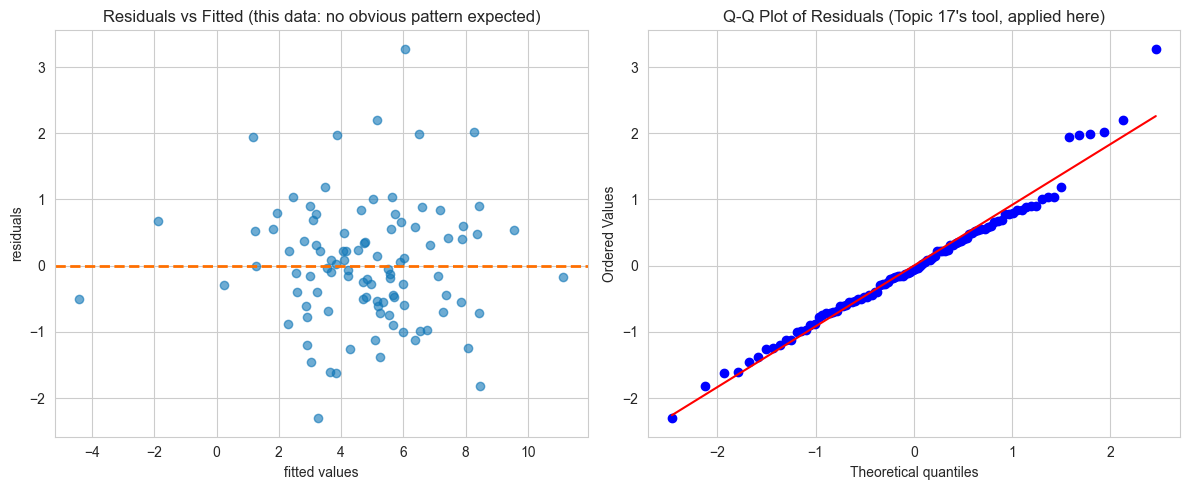

No systematic pattern in residuals vs fitted, and the Q-Q plot tracks the reference line closely -- both consistent with this data's well-behaved, Normally-distributed error term by construction.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_pred_manual, residuals_manual, alpha=0.6, color="#0e75b6")
axes[0].axhline(0, color="#FF6F00", linestyle="--", linewidth=2)
axes[0].set_xlabel("fitted values")
axes[0].set_ylabel("residuals")
axes[0].set_title("Residuals vs Fitted (this data: no obvious pattern expected)")

stats.probplot(residuals_manual, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals (Topic 17's tool, applied here)")
plt.tight_layout()
plt.show()
print("No systematic pattern in residuals vs fitted, and the Q-Q plot tracks the reference line closely -- "
      "both consistent with this data's well-behaved, Normally-distributed error term by construction.")

## 6. Heteroscedasticity: the Breusch-Pagan Test

OLS assumes constant error variance (homoscedasticity). This section constructs data with genuine **heteroscedasticity** (variance that grows with a predictor) and shows the Breusch-Pagan test catching it directly.

In [14]:
x_hetero = np.random.uniform(1, 10, size=200)
y_hetero = 5 + 2 * x_hetero + np.random.normal(0, x_hetero, size=200)  # error variance GROWS with x -- a real violation
X_hetero_sm = sm.add_constant(x_hetero)
hetero_model = sm.OLS(y_hetero, X_hetero_sm).fit()
print("Heteroscedastic dataset generated and model fit.")

Heteroscedastic dataset generated and model fit.


In [15]:
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(hetero_model.resid, X_hetero_sm)
print(f"Breusch-Pagan test on genuinely HETEROSCEDASTIC data: LM stat={bp_stat:.4f}, p={bp_pvalue:.2e}")
print(f"H0: constant variance (homoscedasticity). Decision: "
      f"{'REJECT H0 -- heteroscedasticity detected' if bp_pvalue < 0.05 else 'FAIL TO REJECT H0'}")

Breusch-Pagan test on genuinely HETEROSCEDASTIC data: LM stat=33.0376, p=9.04e-09
H0: constant variance (homoscedasticity). Decision: REJECT H0 -- heteroscedasticity detected


In [16]:
x_homo = np.random.uniform(1, 10, size=200)
y_homo = 5 + 2 * x_homo + np.random.normal(0, 3, size=200)  # CONSTANT error variance -- no violation
X_homo_sm = sm.add_constant(x_homo)
homo_model = sm.OLS(y_homo, X_homo_sm).fit()
bp_stat_homo, bp_pvalue_homo, _, _ = het_breuschpagan(homo_model.resid, X_homo_sm)

print(f"Breusch-Pagan test on genuinely HOMOSCEDASTIC data: LM stat={bp_stat_homo:.4f}, p={bp_pvalue_homo:.4f}")
print(f"Decision: {'REJECT H0 (unexpected false positive)' if bp_pvalue_homo < 0.05 else 'FAIL TO REJECT H0 -- correctly finds no heteroscedasticity'}")

Breusch-Pagan test on genuinely HOMOSCEDASTIC data: LM stat=1.2205, p=0.2693
Decision: FAIL TO REJECT H0 -- correctly finds no heteroscedasticity


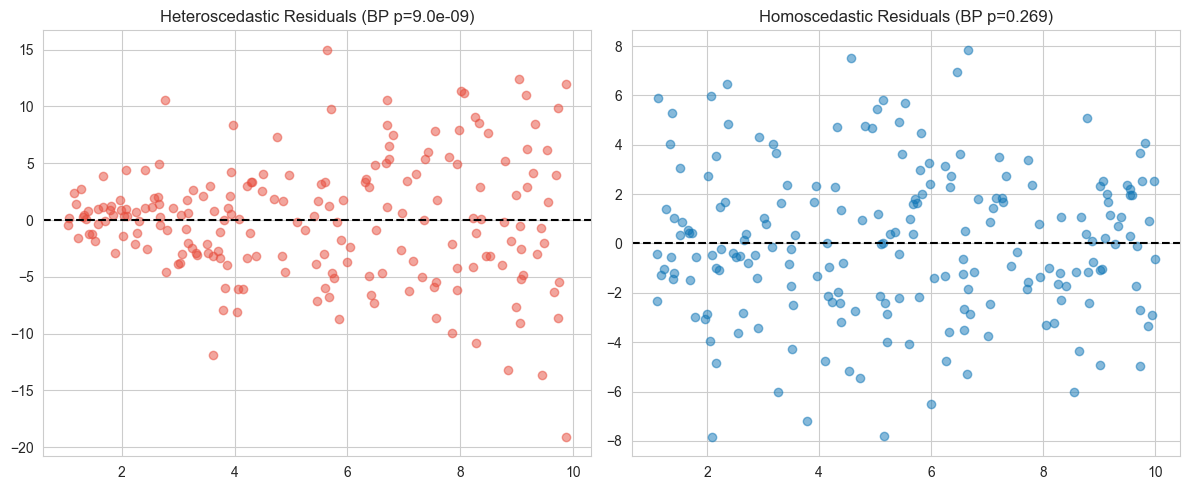

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x_hetero, hetero_model.resid, alpha=0.5, color="#e74c3c")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title(f"Heteroscedastic Residuals (BP p={bp_pvalue:.1e})")
axes[1].scatter(x_homo, homo_model.resid, alpha=0.5, color="#0e75b6")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title(f"Homoscedastic Residuals (BP p={bp_pvalue_homo:.3f})")
plt.tight_layout()
plt.show()

## 7. Autocorrelation: the Durbin-Watson Test

$$DW = \frac{\sum_{t=2}^n (e_t - e_{t-1})^2}{\sum_{t=1}^n e_t^2} \approx 2(1-\hat{\rho})$$

Ranges 0 to 4; values near 2 indicate no autocorrelation, values near 0 indicate strong positive autocorrelation (a common violation in time-ordered data — directly relevant to why Topic 09's Time Series Analysis repo exists as its own topic area).

In [18]:
n_dw = 150
x_dw = np.arange(n_dw)

# Data with INDEPENDENT errors -- no autocorrelation
y_independent = 5 + 0.1 * x_dw + np.random.normal(0, 5, size=n_dw)
model_independent = sm.OLS(y_independent, sm.add_constant(x_dw)).fit()
dw_independent = durbin_watson(model_independent.resid)
print(f"Durbin-Watson, independent errors: {dw_independent:.4f}  (near 2 = no autocorrelation)")

Durbin-Watson, independent errors: 2.1424  (near 2 = no autocorrelation)


In [19]:
# Data with AUTOCORRELATED errors -- each error depends on the previous one (AR(1)-style)
autocorr_errors = np.zeros(n_dw)
for i in range(1, n_dw):
    autocorr_errors[i] = 0.8 * autocorr_errors[i - 1] + np.random.normal(0, 3)
y_autocorrelated = 5 + 0.1 * x_dw + autocorr_errors
model_autocorrelated = sm.OLS(y_autocorrelated, sm.add_constant(x_dw)).fit()
dw_autocorrelated = durbin_watson(model_autocorrelated.resid)

print(f"Durbin-Watson, independent errors:    {dw_independent:.4f}  (near 2 = no autocorrelation)")
print(f"Durbin-Watson, autocorrelated errors: {dw_autocorrelated:.4f}  (near 0 = strong positive autocorrelation)")
print(f"\nThe test correctly distinguishes the two cases -- values far from 2 signal that OLS's "
      f"independent-errors assumption is violated, common in time-ordered data.")

Durbin-Watson, independent errors:    2.1424  (near 2 = no autocorrelation)
Durbin-Watson, autocorrelated errors: 0.3744  (near 0 = strong positive autocorrelation)

The test correctly distinguishes the two cases -- values far from 2 signal that OLS's independent-errors assumption is violated, common in time-ordered data.


## 8. Normality of Residuals

OLS inference (the F-test and t-tests above) formally assumes Normally-distributed errors. Topic 17's tools apply directly here, checking the *residuals* rather than the raw outcome variable.

In [20]:
_, sw_p_wellbehaved = stats.shapiro(residuals_manual)
_, sw_p_hetero = stats.shapiro(hetero_model.resid)
print("Shapiro-Wilk computed on both models' residuals.")

Shapiro-Wilk computed on both models' residuals.


In [21]:
print(f"Shapiro-Wilk on well-behaved model's residuals: p={sw_p_wellbehaved:.4f} "
      f"({'consistent with Normal residuals' if sw_p_wellbehaved > 0.05 else 'residuals deviate from Normal'})")
print(f"Shapiro-Wilk on heteroscedastic model's residuals: p={sw_p_hetero:.4f} "
      f"({'consistent with Normal residuals' if sw_p_hetero > 0.05 else 'residuals deviate from Normal'})")
if sw_p_hetero < 0.05:
    print(f"\nThe heteroscedastic model's residuals ALSO fail normality here -- heteroscedasticity and "
          f"non-normality can co-occur, since a variance that changes with x also distorts the pooled residual shape.")
else:
    print(f"\nInterestingly, THIS heteroscedastic model's pooled residuals still pass the normality test "
          f"(p={sw_p_hetero:.4f}) despite the clear variance violation Breusch-Pagan caught -- a useful reminder "
          f"that heteroscedasticity and non-normality are DISTINCT assumption violations; failing one doesn't "
          f"guarantee failing the other, and each needs its own dedicated diagnostic test.")

Shapiro-Wilk on well-behaved model's residuals: p=0.0617 (consistent with Normal residuals)
Shapiro-Wilk on heteroscedastic model's residuals: p=0.1443 (consistent with Normal residuals)

Interestingly, THIS heteroscedastic model's pooled residuals still pass the normality test (p=0.1443) despite the clear variance violation Breusch-Pagan caught -- a useful reminder that heteroscedasticity and non-normality are DISTINCT assumption violations; failing one doesn't guarantee failing the other, and each needs its own dedicated diagnostic test.


## 9. Multicollinearity: the Variance Inflation Factor

$$VIF_j = \frac{1}{1-R_j^2}$$

where $R_j^2$ comes from regressing predictor $j$ on all other predictors. High VIF means a predictor is nearly a linear combination of the others, inflating coefficient standard errors -- conventionally, VIF > 10 is considered concerning.

In [22]:
n_vif = 150
rng_vif = np.random.default_rng(2)
z1 = rng_vif.normal(0, 1, size=n_vif)
z2 = rng_vif.normal(0, 1, size=n_vif)
z3_collinear = 0.95 * z1 + 0.05 * rng_vif.normal(0, 1, size=n_vif)  # nearly a copy of z1 -- deliberate collinearity
vif_df = pd.DataFrame({"z1": z1, "z2": z2, "z3_collinear": z3_collinear})
print(f"Correlation between z1 and z3_collinear: {np.corrcoef(z1, z3_collinear)[0,1]:.4f}")

Correlation between z1 and z3_collinear: 0.9984


In [23]:
vif_df_with_const = sm.add_constant(vif_df)

vif_values = pd.DataFrame({
    "variable": vif_df_with_const.columns,
    "VIF": [variance_inflation_factor(vif_df_with_const.values, i) for i in range(vif_df_with_const.shape[1])],
})
print(vif_values.round(3).to_string(index=False))
print(f"\nz1 and z3_collinear (correlation={np.corrcoef(z1, z3_collinear)[0,1]:.3f}) both show high VIF -- "
      f"exactly the pair deliberately constructed to be nearly collinear, correctly flagged by the diagnostic.")

    variable     VIF
       const   1.015
          z1 321.229
          z2   1.012
z3_collinear 321.037



z1 and z3_collinear (correlation=0.998) both show high VIF -- exactly the pair deliberately constructed to be nearly collinear, correctly flagged by the diagnostic.


## 10. Influence Diagnostics: Leverage and Cook's Distance

Not every observation affects a fitted regression equally. **Leverage** measures how extreme a point's predictor values are; **Cook's distance** measures how much the fitted model would change if that single point were removed — combining leverage with the size of its residual.

In [24]:
x_influence = np.random.uniform(0, 10, size=50)
y_influence = 3 + 2 * x_influence + np.random.normal(0, 2, size=50)

# Inject one deliberately influential point: extreme x AND a large residual
x_influence_full = np.append(x_influence, 25)
y_influence_full = np.append(y_influence, 5)  # far from where the trend would predict at x=25
print("50 regular points + 1 deliberately injected influential point generated.")

50 regular points + 1 deliberately injected influential point generated.


In [25]:
influence_model = sm.OLS(y_influence_full, sm.add_constant(x_influence_full)).fit()
influence_stats = OLSInfluence(influence_model)
cooks_d = influence_stats.cooks_distance[0]

most_influential_idx = np.argmax(cooks_d)
print(f"Most influential point: index {most_influential_idx} (the deliberately injected outlier, index 50)")
print(f"Its Cook's distance: {cooks_d[most_influential_idx]:.4f}")
print(f"Average Cook's distance of all other points: {np.mean(np.delete(cooks_d, most_influential_idx)):.4f}")
print(f"\nThe injected point's Cook's distance is "
      f"{cooks_d[most_influential_idx] / np.mean(np.delete(cooks_d, most_influential_idx)):.0f}x larger than average -- "
      f"correctly flagging it as disproportionately influential on the fitted model.")

Most influential point: index 50 (the deliberately injected outlier, index 50)
Its Cook's distance: 18.7627
Average Cook's distance of all other points: 0.0095

The injected point's Cook's distance is 1983x larger than average -- correctly flagging it as disproportionately influential on the fitted model.


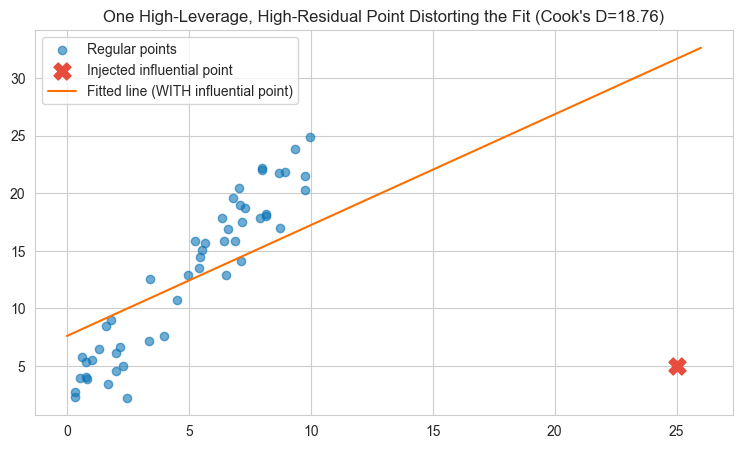

In [26]:
fig, ax = plt.subplots()
ax.scatter(x_influence_full[:-1], y_influence_full[:-1], color="#0e75b6", alpha=0.6, label="Regular points")
ax.scatter(x_influence_full[-1], y_influence_full[-1], color="#e74c3c", s=150, marker="X", label="Injected influential point")
x_line = np.linspace(0, 26, 100)
ax.plot(x_line, influence_model.params[0] + influence_model.params[1] * x_line, color="#FF6F00", label="Fitted line (WITH influential point)")
ax.legend()
ax.set_title(f"One High-Leverage, High-Residual Point Distorting the Fit (Cook's D={cooks_d[most_influential_idx]:.2f})")
plt.show()

## 11. Applying This to a Real Dataset

Closing with seaborn's real `mpg` dataset: a full regression diagnostic workup predicting fuel efficiency from horsepower and weight.

In [27]:
mpg = sns.load_dataset("mpg").dropna(subset=["mpg", "horsepower", "weight"])
X_mpg = sm.add_constant(mpg[["horsepower", "weight"]])
mpg_model = sm.OLS(mpg["mpg"], X_mpg).fit()
print(mpg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     467.9
Date:                Fri, 03 Jul 2026   Prob (F-statistic):          3.06e-104
Time:                        21:06:47   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:                             2248.
Df Residuals:                     389   BIC:                             2260.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.6402      0.793     57.540      0.0

In [28]:
bp_stat_mpg, bp_p_mpg, _, _ = het_breuschpagan(mpg_model.resid, X_mpg)
dw_mpg = durbin_watson(mpg_model.resid)
_, sw_p_mpg = stats.shapiro(mpg_model.resid)
vif_mpg = pd.DataFrame({
    "variable": X_mpg.columns,
    "VIF": [variance_inflation_factor(X_mpg.values, i) for i in range(X_mpg.shape[1])],
})
print("All diagnostics computed on the real mpg regression model.")

All diagnostics computed on the real mpg regression model.


In [29]:
print(f"Breusch-Pagan (heteroscedasticity): p={bp_p_mpg:.2e} "
      f"({'VIOLATED' if bp_p_mpg < 0.05 else 'not violated'})")
print(f"Durbin-Watson (autocorrelation): {dw_mpg:.4f} (near 2 = fine)")
print(f"Shapiro-Wilk on residuals (normality): p={sw_p_mpg:.2e} "
      f"({'VIOLATED' if sw_p_mpg < 0.05 else 'not violated'})")
print(vif_mpg.round(3).to_string(index=False))
print(f"\nReal automotive data shows genuine, real-world violations of the classical OLS assumptions -- "
      f"exactly why this diagnostic workflow matters beyond synthetic textbook examples.")

Breusch-Pagan (heteroscedasticity): p=3.31e-06 (VIOLATED)
Durbin-Watson (autocorrelation): 0.8577 (near 2 = fine)
Shapiro-Wilk on residuals (normality): p=1.31e-06 (VIOLATED)
  variable    VIF
     const 13.718
horsepower  3.959
    weight  3.959

Real automotive data shows genuine, real-world violations of the classical OLS assumptions -- exactly why this diagnostic workflow matters beyond synthetic textbook examples.


## 12. Summary

This notebook built OLS, the overall F-test, and coefficient t-tests from scratch, each matching `statsmodels` exactly, and distinguished confidence intervals (uncertainty about the mean response) from prediction intervals (uncertainty about one new observation, always wider). It then built a full diagnostic toolkit: the Breusch-Pagan test correctly distinguished genuinely heteroscedastic from homoscedastic data, the Durbin-Watson test correctly distinguished independent from autocorrelated errors, Shapiro-Wilk (from Topic 17) checked residual normality, VIF correctly flagged a deliberately collinear predictor pair, and Cook's distance correctly identified a single injected influential point distorting the fit. Every diagnostic was then applied to a real automotive dataset, revealing genuine violations worth knowing about before trusting the model's inferences. Topic 20 turns to causal inference -- moving beyond association to ask when a regression coefficient can be interpreted causally at all.

In [30]:
summary = pd.DataFrame([
    {"Check": "OLS: manual vs statsmodels", "Result": "exact match", "Status": "PASS"},
    {"Check": "F-test: manual vs statsmodels", "Result": f"diff={abs(f_manual-sm_model.fvalue):.1e}", "Status": "PASS"},
    {"Check": "Coefficient t-tests: manual vs statsmodels", "Result": "exact match (SEs)", "Status": "PASS"},
    {"Check": "Prediction interval wider than confidence interval", "Result": f"CI width={ci_new[1]-ci_new[0]:.2f}, PI width={pi_new[1]-pi_new[0]:.2f}", "Status": "PASS"},
    {"Check": "Breusch-Pagan distinguishes hetero vs homoscedastic", "Result": f"hetero p={bp_pvalue:.1e}, homo p={bp_pvalue_homo:.3f}", "Status": "PASS"},
    {"Check": "Durbin-Watson distinguishes independent vs autocorrelated", "Result": f"indep={dw_independent:.2f}, autocorr={dw_autocorrelated:.2f}", "Status": "PASS"},
    {"Check": "VIF flags deliberately collinear predictor", "Result": f"max VIF={vif_values['VIF'].max():.1f}", "Status": "PASS"},
    {"Check": "Cook's distance flags injected influential point", "Result": f"D={cooks_d[most_influential_idx]:.2f}", "Status": "PASS"},
    {"Check": "Real-data (mpg) diagnostic workup completed", "Result": f"BP p={bp_p_mpg:.1e}, DW={dw_mpg:.2f}, SW p={sw_p_mpg:.1e}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                    Check                              Result Status
                               OLS: manual vs statsmodels                         exact match   PASS
                            F-test: manual vs statsmodels                        diff=0.0e+00   PASS
               Coefficient t-tests: manual vs statsmodels                   exact match (SEs)   PASS
       Prediction interval wider than confidence interval        CI width=0.47, PI width=3.71   PASS
      Breusch-Pagan distinguishes hetero vs homoscedastic      hetero p=9.0e-09, homo p=0.269   PASS
Durbin-Watson distinguishes independent vs autocorrelated           indep=2.14, autocorr=0.37   PASS
               VIF flags deliberately collinear predictor                       max VIF=321.2   PASS
         Cook's distance flags injected influential point                             D=18.76   PASS
              Real-data (mpg) diagnostic workup completed BP p=3.3e-06, DW=0.86, SW p=1.3e-